# Template Matching Analysis

Analyze template matches for a single session:
- Offline template matching using SLEAP and DANNCE data
- Compare online (SLEAP) vs offline matches
- Visualize matched behavior trajectories in PC space
- Generate template match videos

In [5]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

from config import NODES, EDGES, NODE_IDX
from data_io import (
    load_aligned_data, load_sleap_dannce_keys, load_template,
    load_behavior_log, load_session_df, load_frame_mapping, load_sleap_keys_3d,
    load_dannce_predictions,
)
from skeleton import normalize_skeleton_batch, project_to_pcs
from processing import get_template_match_indices, closest_indices

from scipy.ndimage import median_filter

%matplotlib inline

In [147]:
# --- Configuration ---
rat = 'R1'
session = '2025_12_02_1'
template_file = 'R1_template_1.npz'
n_components = 2  # number of PCs for template matching

## Load data

In [61]:
pc_template.shape

(30, 2)

In [ ]:
# Load template
template_data = load_template(rat, template_file)
pc_template = template_data['template'][:,:n_components]  # (template_length, n_components)
pc_weights = template_data['pc_weights']  # (n_pcs, n_features)
feature_means = template_data['feature_means']
bounds = float(template_data['bounds'])
pcs_to_use = template_data['pcs_to_use']

template_filt = median_filter(pc_template, size=(5,1))

template_length = pc_template.shape[0]
print(f'Template length: {template_length} frames')
print(f'Bounds: {bounds}')
print(f'PCs used: {pcs_to_use}')

# Template bounds: uniform bounds applied per PC per timepoint      
feature_stds = template_data['feature_stds']
pc_template_bounds = np.ones_like(pc_template) * bounds * feature_stds[:n_components]

Template length: 30 frames
Bounds: 1.5
PCs used: [0 1]


In [149]:
from data_io import load_sleap_dannce_keys as _load_keys, load_aligned_data as _load_aligned

def load_template_from_file(template_data):
      # ── Load the template origin session─────────────────────────────────────
      temp_origin_str = str(template_data['temp_origin_file'])  # e.g. 'R1/2026_02_04_2'                                                             
      temp_rat, temp_session = temp_origin_str.strip().split('/')
      temp_frame_idx = int(template_data['temp_origin_idx'])                    
                                                                                
      print(f'Template origin: {temp_rat}/{temp_session}  frame{temp_frame_idx}')                                                            
                                                                                
      # Load the origin session keypoints (raw, unfiltered) at full resolution
      orig_keys = _load_keys(temp_rat, temp_session)
      orig_aligned = _load_aligned(temp_rat, temp_session)
      orig_aligned_idx = orig_aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]             
                                                                                
      orig_dannce = orig_keys['dannce_keys_3D']                                 
      if orig_dannce.ndim == 4:
          orig_dannce = orig_dannce.squeeze(axis=1).transpose(0, 2, 1)
      else:                                                                     
          orig_dannce = np.transpose(orig_dannce, [0, 2, 1])
      orig_dannce = orig_dannce[orig_aligned_idx, :, :]  # align to SLEAP timeline                                                                      
      orig_dannce = median_filter(orig_dannce, size=(11, 1, 1))
                                                                                
      orig_sleap = orig_keys['sleap_keys_3D']
      orig_sleap = median_filter(orig_sleap, size=(11, 1, 1))   

      sleap_flipped = orig_sleap.copy()
      sleap_flipped[:, :, 2] = -sleap_flipped[:, :, 2]   
                                                                                
      def _extract_template_pcs(arr):                                           
          start_1 = temp_frame_idx                                              
          if start_1 < 0:                                                       
              print(f'WARNING: template window starts before frame 0(start={start_1}). Clamping.')                                                
              start_1 = 0
          end_1 = temp_frame_idx + template_length                              
                  
          window = arr[start_1:end_1]
          if window.shape[0] < template_length:
              pad = template_length - window.shape[0]                           
              window = np.concatenate([window[:1].repeat(pad, axis=0), window], axis=0)                                                                       
                  
          rot, _, _ = normalize_skeleton_batch(window)                          
          flat = rot.reshape(template_length, -1)
          return (flat - feature_means) @ pc_weights.T  # (T, n_pcs)            
                                                                                
      dannce_template_pcs = _extract_template_pcs(orig_dannce)
      sleap_template_pcs = _extract_template_pcs(sleap_flipped)                    
                                                                                
      return sleap_template_pcs, dannce_template_pcs

sleap_template_pcs, dannce_template_pcs = load_template_from_file(template_data)


KeyError: 'temp_origin_file'

In [150]:
# Load keypoint data
keys = load_sleap_dannce_keys(rat, session)
aligned = load_aligned_data(rat, session)

aligned_indices = aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]

sleap_3d = keys['sleap_keys_3D']
sleap_3d = median_filter(keys['sleap_keys_3D'], size=(11, 1, 1))
dannce_3d = keys['dannce_keys_3D']
if dannce_3d.ndim == 4:
    dannce_3d = dannce_3d.squeeze(axis=1).transpose(0, 2, 1)
else:
    
    dannce_3d = np.transpose(dannce_3d, [0,2,1])

dannce_3d = dannce_3d[aligned_indices, :,:]

dannce_3d = median_filter(dannce_3d, size=(11, 1, 1))

print(f'SLEAP: {sleap_3d.shape}, DANNCE: {dannce_3d.shape}')

SLEAP: (36000, 23, 3), DANNCE: (36000, 23, 3)


## (Optional) Apply MLP corrector to SLEAP

If `APPLY_CORRECTOR = True` below, this cell:
1. Loads a trained world-space MLP corrector from `corrector/checkpoints/`.
2. Fits a per-session 7-DoF Procrustes on the first 5 minutes (the calibration epoch) to map raw SLEAP → DANNCE world space.
3. Applies the MLP to Procrustes-aligned SLEAP, then inverse-Procrustes back to SLEAP world space.
4. **Replaces `sleap_3d`** with the corrected version, so all downstream cells (z-flip → normalize → project to PCs → template matching) operate transparently on corrected keypoints.

Set `APPLY_CORRECTOR = False` to keep the original raw SLEAP and skip everything below.

The default checkpoint is the temporal R1+R2+R3 model — the current best across all rats.

In [130]:
# ---- Toggle ---------------------------------------------------------------
APPLY_CORRECTOR  = True
CORRECTOR_CKPT   = 'corrector/checkpoints/R1R2R3_world_temporal_mlp.pt'
CALIBRATION_MIN  = 5.0    # minutes of pre-task data used for the Procrustes fit
MAX_PROCRUSTES_RESIDUAL = 60.0   # mm; abort if SLEAP/DANNCE aren't co-calibrated
# ---------------------------------------------------------------------------

if APPLY_CORRECTOR:
    import sys, os
    # Ensure the corrector package is on the path. The notebook is run from
    # CLIRB_analyses/ in the existing setup, so a relative add works.
    sys.path.insert(0, os.path.abspath('.'))
    sys.path.insert(0, os.path.abspath('experiments'))
    import torch, numpy as np
    from corrector.world_alignment import calibration_indices, fit_procrustes
    from corrector.models import build_model

    # ---- Load the checkpoint ---------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ck = torch.load(CORRECTOR_CKPT, map_location=device, weights_only=False)
    model_kwargs = dict(hidden=ck.get('hidden', 128),
                        n_hidden_layers=ck.get('n_hidden_layers', 2))
    if ck['model_name'] == 'temporal_mlp':
        model_kwargs['ctx'] = ck.get('ctx', 5)
    model = build_model(ck['model_name'], **model_kwargs)
    model.load_state_dict(ck['state_dict'])
    model = model.to(device).eval()
    eval_ctx = ck.get('ctx', 1)
    print(f'Loaded corrector: {ck["model_name"]}  ctx={eval_ctx}  '
          f'tag={ck.get("tag")}  best_val_mse={ck.get("best_val_mse"):.2f}')

    # ---- Procrustes fit on the calibration epoch -------------------------
    # SLEAP and DANNCE were already median-filtered above; for fitting we use
    # the same arrays that downstream uses (SLEAP world space, DANNCE world
    # space resampled to SLEAP frame rate via aligned_indices).
    sleap_world  = sleap_3d.astype(np.float32)         # (T, 23, 3)
    dannce_world = dannce_3d.astype(np.float32)        # already at SLEAP frame rate
    cal_idx = calibration_indices(len(sleap_world), CALIBRATION_MIN, sleap_hz=20.0,
                                  n_sample=1000, seed=0)
    tx = fit_procrustes(sleap_world[cal_idx], dannce_world[cal_idx], try_z_flip=True)
    print(f'Procrustes residual: {tx["residual"]:.2f} mm  scale={tx["s"]:.4f}  z_flipped={tx["z_flipped"]}')
    if tx['residual'] > MAX_PROCRUSTES_RESIDUAL:
        raise RuntimeError(
            f'Procrustes residual {tx["residual"]:.1f} mm exceeds threshold '
            f'{MAX_PROCRUSTES_RESIDUAL} mm — SLEAP and DANNCE may be uncalibrated. '
            f'Skip the corrector for this session.')

    # ---- Run the corrector ----------------------------------------------
    sl_aligned = tx['apply'](sleap_world).astype(np.float32)   # SLEAP -> DANNCE world space
    sl_corrected_dn_space = np.empty_like(sl_aligned)
    if eval_ctx <= 1:
        with torch.no_grad():
            for i in range(0, len(sl_aligned), 8192):
                xt = torch.from_numpy(sl_aligned[i:i+8192]).to(device)
                sl_corrected_dn_space[i:i+8192] = model(xt).cpu().numpy()
    else:
        T, ctx = len(sl_aligned), eval_ctx
        padded = np.concatenate([np.repeat(sl_aligned[:1], ctx-1, axis=0), sl_aligned], axis=0)
        with torch.no_grad():
            for i in range(0, T, 8192):
                idx = np.arange(i, min(i+8192, T))
                wins = np.stack([padded[s:s+ctx] for s in idx], axis=0)
                xt = torch.from_numpy(wins).to(device)
                sl_corrected_dn_space[i:i+len(idx)] = model(xt).cpu().numpy()
    sleap_corrected_world = tx['apply_inverse'](sl_corrected_dn_space).astype(np.float32)

    # ---- Replace sleap_3d so downstream uses corrected keypoints ---------
    sleap_3d_uncorrected = sleap_3d.copy()   # keep a copy in case you want to compare
    sleap_3d = sleap_corrected_world
    print(f'sleap_3d replaced with corrected keypoints. Original kept as sleap_3d_uncorrected.')
else:
    print('Corrector skipped (APPLY_CORRECTOR=False).')



Loaded corrector: temporal_mlp  ctx=5  tag=R1R2R3  best_val_mse=243.30
Procrustes residual: 14.29 mm  scale=0.9991  z_flipped=True
sleap_3d replaced with corrected keypoints. Original kept as sleap_3d_uncorrected.


## Normalize and project to PC space

In [151]:
# Use the canonical project_to_pcs from skeleton.py — it takes feature_means
# from the TEMPLATE (loaded above), not a recomputed per-session mean.
#
# Recomputing the mean per session shifts the projection in PC space relative
# to where the template lives, which can drive every frame outside the
# template bounds (especially after applying the corrector, since corrected
# SLEAP lives in DANNCE coordinate space and has a different mean than raw
# SLEAP). Always pass the stored feature_means.
from skeleton import project_to_pcs

In [152]:
# SLEAP: flip z, normalize, project — using TEMPLATE feature_means.
sleap_flipped = sleap_3d.copy()
sleap_flipped[:, :, 2] = -sleap_flipped[:, :, 2]
sleap_rotated, _, _ = normalize_skeleton_batch(sleap_flipped)
sleap_pcs = project_to_pcs(sleap_rotated, pc_weights, feature_means)

# DANNCE: normalize, project (no z-flip; DANNCE is already in template coords).
dannce_rotated, _, _ = normalize_skeleton_batch(dannce_3d)
dannce_pcs = project_to_pcs(dannce_rotated, pc_weights, feature_means)

print(f'SLEAP PCs: {sleap_pcs.shape}')
print(f'DANNCE PCs: {dannce_pcs.shape}')

SLEAP PCs: (36000, 10)
DANNCE PCs: (36000, 10)


## Sanity check: compare SLEAP PCs to behavior log

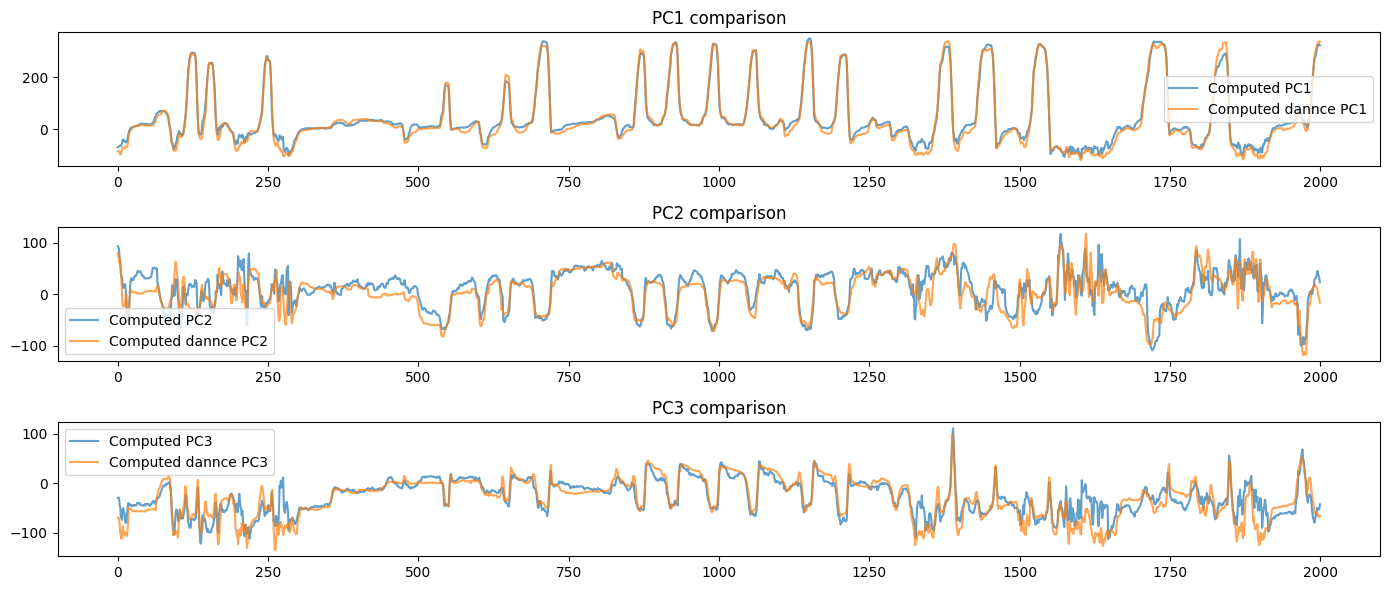

In [153]:
# If sleap_keys_PCs exists in the data, compare
if 'sleap_keys_PCs' in keys:
    stored_pcs = keys['sleap_keys_PCs']
    fig, axes = plt.subplots(3, 1, figsize=(14, 6))
    n_show = min(2000, len(sleap_pcs))
    
    axes[0].plot(sleap_pcs[:n_show, 0], label='Computed PC1', alpha=0.7)
    axes[0].plot(dannce_pcs[:n_show,0], label='Computed dannce PC1', alpha=0.7)
    #axes[0].plot(stored_pcs[:n_show, 0], label='Stored PC1', alpha=0.7)
    axes[0].legend()
    axes[0].set_title('PC1 comparison')
    
    axes[1].plot(sleap_pcs[:n_show, 1], label='Computed PC2', alpha=0.7) 
    axes[1].plot(dannce_pcs[:n_show,1], label='Computed dannce PC2', alpha=0.7)
    #axes[1].plot(stored_pcs[:n_show, 1], label='Stored PC2', alpha=0.7)
    axes[1].legend()
    axes[1].set_title('PC2 comparison')

    axes[2].plot(sleap_pcs[:n_show, 2], label='Computed PC3', alpha=0.7)
    axes[2].plot(dannce_pcs[:n_show,2], label='Computed dannce PC3', alpha=0.7)
    #axes[1].plot(stored_pcs[:n_show, 1], label='Stored PC2', alpha=0.7)
    axes[2].legend()
    axes[2].set_title('PC3 comparison')
    
    plt.tight_layout()
    plt.show()

In [102]:
print(np.std(sleap_pcs[:,0]))
print(np.std(dannce_pcs[:,0]))

print(np.std(sleap_pcs[:,1]))
print(np.std(dannce_pcs[:,1]))

print(np.std(sleap_pcs[:,2]))
print(np.std(dannce_pcs[:,2]))

133.3963072093235
141.76801092063957
47.007222804605995
46.1480175080117
36.897072684789094
37.36742907183088


In [75]:
pc_error = np.mean((dannce_pcs-sleap_pcs)**2, axis=0) #sleap med filter 11, no dannce filter
print(pc_error)

[ 257.64472175  418.10500316  521.21454139 1154.83167776  472.735156
  272.17682031  545.57943896  306.49140674  262.42618421  252.17921378]


In [76]:
pc_error = np.mean((dannce_pcs-sleap_pcs)**2, axis=0) #no sleap or dannce med filter
print(pc_error)

[ 257.64472175  418.10500316  521.21454139 1154.83167776  472.735156
  272.17682031  545.57943896  306.49140674  262.42618421  252.17921378]


In [77]:
pc_error = np.mean((dannce_pcs-sleap_pcs)**2, axis=0) #sleap filter 11, dannce filter 25
print(pc_error)

[ 257.64472175  418.10500316  521.21454139 1154.83167776  472.735156
  272.17682031  545.57943896  306.49140674  262.42618421  252.17921378]


In [78]:
pc_error = np.mean((dannce_pcs-sleap_pcs)**2, axis=0) #sleap filter 11, dannce filter 11 applied after frame alignment
print(pc_error)

[ 257.64472175  418.10500316  521.21454139 1154.83167776  472.735156
  272.17682031  545.57943896  306.49140674  262.42618421  252.17921378]


## Offline template matching

In [79]:
sleap_pcs.shape

(36000, 10)

In [138]:
# Run offline matching on SLEAP PCs
sleap_matches, num_outside = get_template_match_indices(
    sleap_pcs[:,:n_components], pc_template, pc_template_bounds, refractory_frames=template_length
    #sleap_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #sleap_pcs[:,:n_components], sleap_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)
print(f'SLEAP offline matches: {len(sleap_matches)}')

# Run offline matching on DANNCE PCs
dannce_matches, num_outside = get_template_match_indices(
    dannce_pcs[:,:n_components], pc_template, pc_template_bounds, refractory_frames=template_length
    #dannce_pcs[:,:n_components], template_filt, pc_template_bounds, refractory_frames=template_length
    #dannce_pcs[:,:n_components], dannce_template_pcs[:,:2], pc_template_bounds, refractory_frames=template_length
)
print(f'DANNCE offline matches: {len(dannce_matches)}')

SLEAP offline matches: 109
DANNCE offline matches: 136


In [117]:
# Load online match info from behavior log if available
try:
    behavior = load_behavior_log(rat, session)
    if 'triggered' in behavior.columns:
        online_triggered = behavior[behavior['triggered'] == 1]['frame'].to_numpy()
        print(f'Online triggered matches: {len(online_triggered)}')
    else:
        online_triggered = None
        print('No triggered column in behavior log')
except Exception as e:
    online_triggered = None
    print(f'Could not load behavior log: {e}')

No triggered column in behavior log


## Visualize matches in PC space

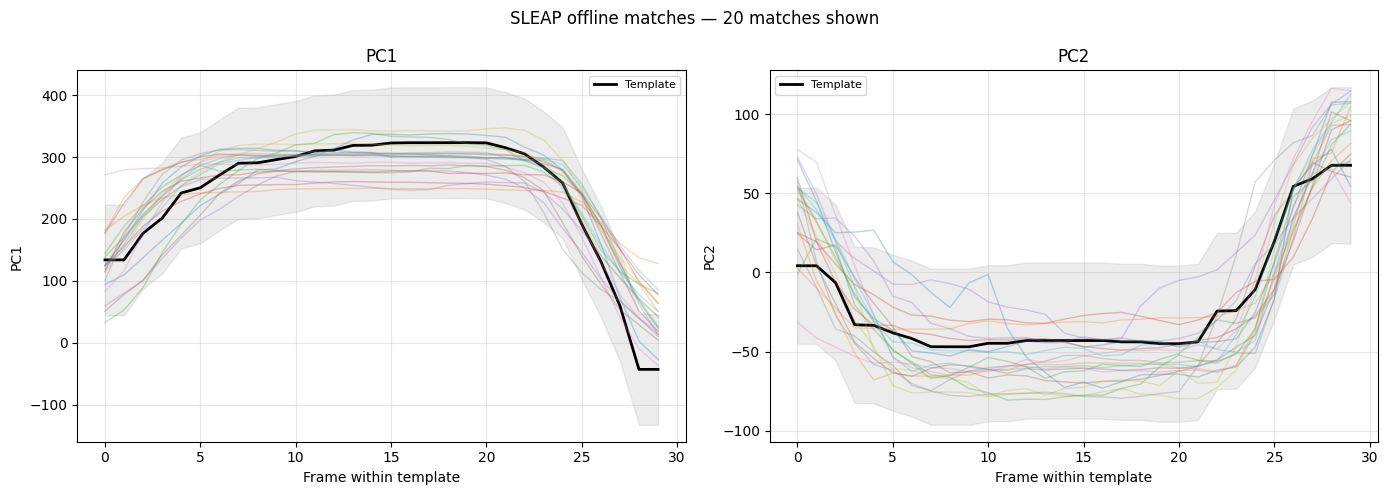

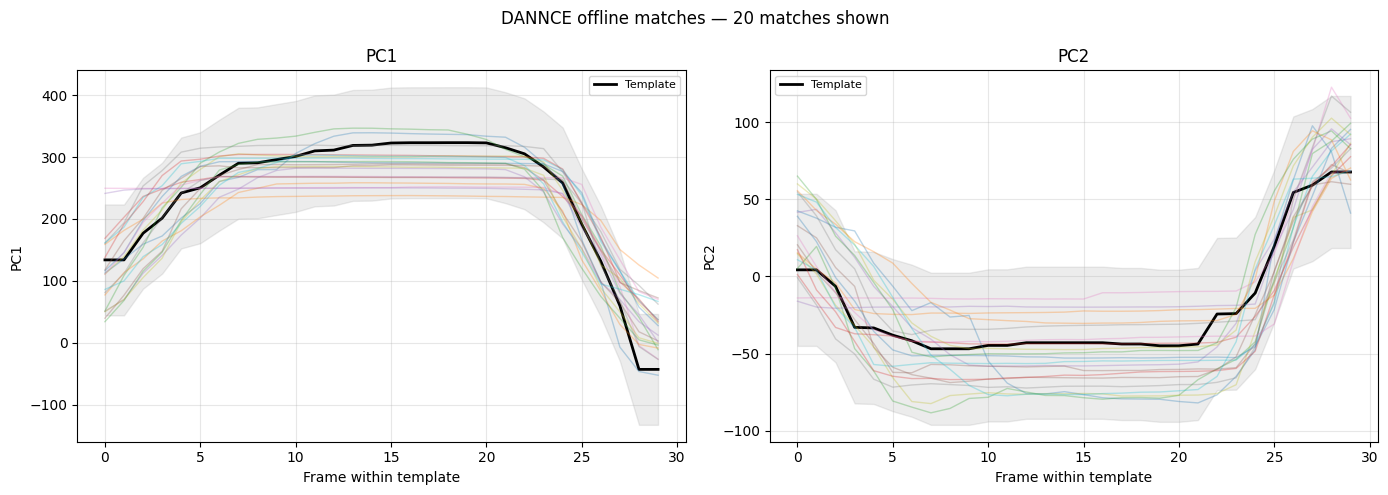

In [139]:
def plot_template_matches(pcs, match_indices, pc_template, pc_template_bounds,
                          n_components=2, title='', max_matches=20):
    """Plot matched PC trajectories against the template."""
    template_length = pc_template.shape[0]
    n_show = min(len(match_indices), max_matches)
    
    fig, axes = plt.subplots(1, n_components, figsize=(7 * n_components, 5))
    if n_components == 1: 
        axes = [axes]
    
    t_axis = np.arange(template_length)
    
    for pc in range(n_components):
        ax = axes[pc]
        # Template and bounds
        ax.plot(t_axis, pc_template[:, pc], 'k-', linewidth=2, label='Template')
        ax.fill_between(t_axis,
                        pc_template[:, pc] - pc_template_bounds[:, pc],
                        pc_template[:, pc] + pc_template_bounds[:, pc],
                        alpha=0.15, color='gray')
        
        # Matched trajectories
        for mi in match_indices[:n_show]:
            start = mi - template_length + 1
            if start < 0:
                continue
            segment = pcs[start:mi + 1, pc]
            ax.plot(t_axis[:len(segment)], segment, alpha=0.3, linewidth=1)
        
        ax.set_xlabel('Frame within template')
        ax.set_ylabel(f'PC{pc + 1}')
        ax.set_title(f'PC{pc + 1}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'{title} — {n_show} matches shown', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_template_matches(sleap_pcs, sleap_matches, template_filt, pc_template_bounds,
                      n_components=n_components, title='SLEAP offline matches')

plot_template_matches(dannce_pcs, dannce_matches, template_filt, pc_template_bounds,
                      n_components=n_components, title='DANNCE offline matches')

## Online vs offline match comparison

In [218]:
def closest_differences(arr1, arr2):
    """For each element in arr1, find the closest element in arr2 and return the difference."""
    diffs = []
    for val in arr1:
        if len(arr2) == 0:
            diffs.append(np.nan)
            continue
        idx = np.argmin(np.abs(arr2 - val))
        diffs.append(val - arr2[idx])
    return np.array(diffs)


if online_triggered is not None and len(online_triggered) > 0:
    online_to_offline = closest_differences(online_triggered, np.array(sleap_matches))
    offline_to_online = closest_differences(np.array(sleap_matches), online_triggered)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(online_triggered, online_to_offline, 'o', markersize=3)
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.5) 
    axes[0].set_xlabel('Online trigger frame')
    axes[0].set_ylabel('Online - closest offline (frames)')
    axes[0].set_title(f'Online→Offline diff (within 50: {np.sum(np.abs(online_to_offline) < 50)})')
    
    axes[1].plot(sleap_matches, offline_to_online, 'o', markersize=3)
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Offline match frame')
    axes[1].set_ylabel('Offline - closest online (frames)')
    axes[1].set_title(f'Offline→Online diff (within 50: {np.sum(np.abs(offline_to_online) < 50)})')
    
    plt.tight_layout()
    plt.show()
else:
    print('No online match data available for comparison')

No online match data available for comparison


## Match timing within session

In [140]:
def closest_match(source_indices, target_indices):
    """
    For each t in target_times, return the index of the closest value in source_times.
    Returns empty array if source_times is empty.
    """

    return np.array([np.argmin(np.abs(np.array(source_indices)-t)) for t in target_indices])

In [141]:
def get_match_overlap(dannce_matches, sleap_matches, thresh=5):

    sleap_only = []
    dannce_only = []
    both = []

    if len(dannce_matches) == 0 and len(sleap_matches) == 0:
        return np.array(sleap_only), np.array(dannce_only), np.array(both)
    elif len(dannce_matches) == 0:
        return np.array(sleap_matches), np.array(dannce_only), np.array(both)
    elif len(sleap_matches) == 0:
        return np.array(sleap_only), np.array(dannce_matches), np.array(both)
    else:

        close_match_sleap = closest_match(dannce_matches, sleap_matches)
        close_match_dannce = closest_match(sleap_matches, dannce_matches)

        both = np.array(sleap_matches)[np.where(np.abs(np.array(sleap_matches) - np.array(dannce_matches)[close_match_sleap])<thresh)]
        sleap_only = np.array(sleap_matches)[np.where(np.abs(np.array(sleap_matches) - np.array(dannce_matches)[close_match_sleap])>=thresh)]
        dannce_only = np.array(dannce_matches)[np.where(np.abs(np.array(dannce_matches) - np.array(sleap_matches)[close_match_dannce])>=thresh)]
        
        return sleap_only, dannce_only, both

In [142]:
sleap_only, dannce_only, both = get_match_overlap(dannce_matches, sleap_matches)

print(sleap_only)
print(len(sleap_only))
print(dannce_only)
print(len(dannce_only))
print(both)
print(len(both))

[ 3668 17495 19452 20120 21928 27793 30669 32426 33386]
9
[ 4383  5664  5741  6312  6725  6867 10259 11144 11461 11506 11601 11688
 12211 12303 12991 16148 18161 18212 18274 20238 22105 23028 23990 24189
 25164 26279 26329 28600 29829 30738 31224 31338 31458 33271 35364 35894]
36
[ 1031  1768  2602  2958  3025  3278  4447  4797  5266  5315  5972  6402
  6445  6684  6994  7116  7199  7376  7656  8290  8337  8758  9028  9879
 10380 10797 11286 11413 11733 11776 12463 12721 12892 13220 14628 14730
 15403 15900 16265 17391 17549 18365 18837 18991 19042 19103 19155 19535
 19947 20344 20781 21277 21365 21425 21999 22198 23121 23696 24817 25017
 26200 26433 26604 27234 27525 27845 27992 28457 30021 30889 30943 31003
 31070 31410 31517 31582 31828 31877 32164 32263 32319 32524 33185 33328
 33436 33566 33660 33720 33772 33831 33887 33982 34033 34289 34989 35155
 35201 35416 35941 35987]
100


In [143]:
print(sleap_matches)
print(len(sleap_matches))
print(dannce_matches)
print(len(dannce_matches))

close_matches = closest_match(dannce_matches, sleap_matches)

print(close_matches)

[1031, 1768, 2602, 2958, 3025, 3278, 3668, 4447, 4797, 5266, 5315, 5972, 6402, 6445, 6684, 6994, 7116, 7199, 7376, 7656, 8290, 8337, 8758, 9028, 9879, 10380, 10797, 11286, 11413, 11733, 11776, 12463, 12721, 12892, 13220, 14628, 14730, 15403, 15900, 16265, 17391, 17495, 17549, 18365, 18837, 18991, 19042, 19103, 19155, 19452, 19535, 19947, 20120, 20344, 20781, 21277, 21365, 21425, 21928, 21999, 22198, 23121, 23696, 24817, 25017, 26200, 26433, 26604, 27234, 27525, 27793, 27845, 27992, 28457, 30021, 30669, 30889, 30943, 31003, 31070, 31410, 31517, 31582, 31828, 31877, 32164, 32263, 32319, 32426, 32524, 33185, 33328, 33386, 33436, 33566, 33660, 33720, 33772, 33831, 33887, 33982, 34033, 34289, 34989, 35155, 35201, 35416, 35941, 35987]
109
[1031, 1767, 2602, 2958, 3024, 3277, 4383, 4447, 4796, 5266, 5314, 5664, 5741, 5971, 6312, 6401, 6444, 6682, 6725, 6867, 6993, 7114, 7197, 7376, 7654, 8289, 8336, 8757, 9026, 9879, 10259, 10379, 10795, 11144, 11284, 11412, 11461, 11506, 11601, 11688, 11732,

In [87]:
aligned_indices

array([ 1061,  1064,  1066, ..., 90993, 90996, 90998], shape=(36000,))

In [88]:
close_matches.dtype

dtype('int64')

In [89]:
np.array(sleap_matches) - np.array(dannce_matches)[close_matches]

array([    1, -5155, -2814,     0,  -230,     0,   259,   309,     0,
           1,    -2,   750,  2340, -1189,  -919,     1,   927,  1688,
       -1291,    -1,    -1,    78,     0,     0])

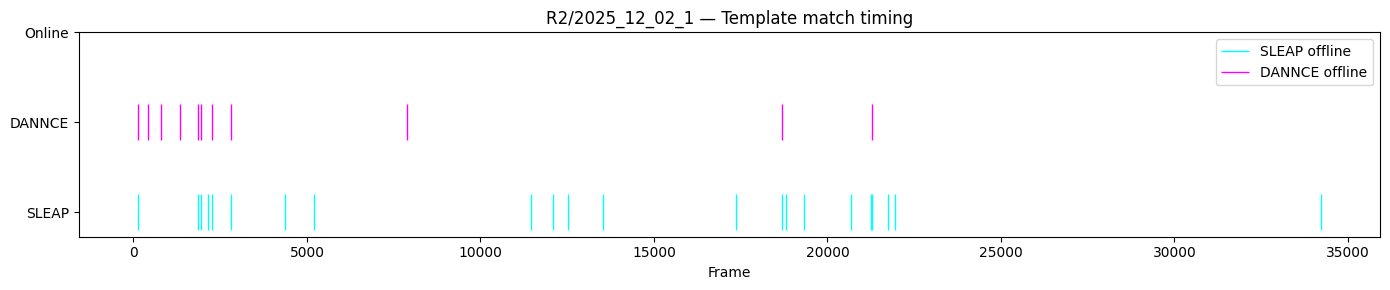

In [122]:
# Plot match times over the session
fig, ax = plt.subplots(figsize=(14, 3))

if len(sleap_matches) > 0:
    ax.vlines(np.array(sleap_matches), 0.8, 1.2, colors='cyan', linewidth=1, label='SLEAP offline')

if len(dannce_matches) > 0:
    ax.vlines(np.array(dannce_matches), 1.8, 2.2, colors='magenta', linewidth=1, label='DANNCE offline')

if online_triggered is not None and len(online_triggered) > 0:
    ax.vlines(online_triggered, 2.8, 3.2, colors='green', linewidth=1, label='Online triggered')

ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['SLEAP', 'DANNCE', 'Online'])
ax.set_xlabel('Frame') 
ax.set_title(f'{rat}/{session} — Template match timing')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

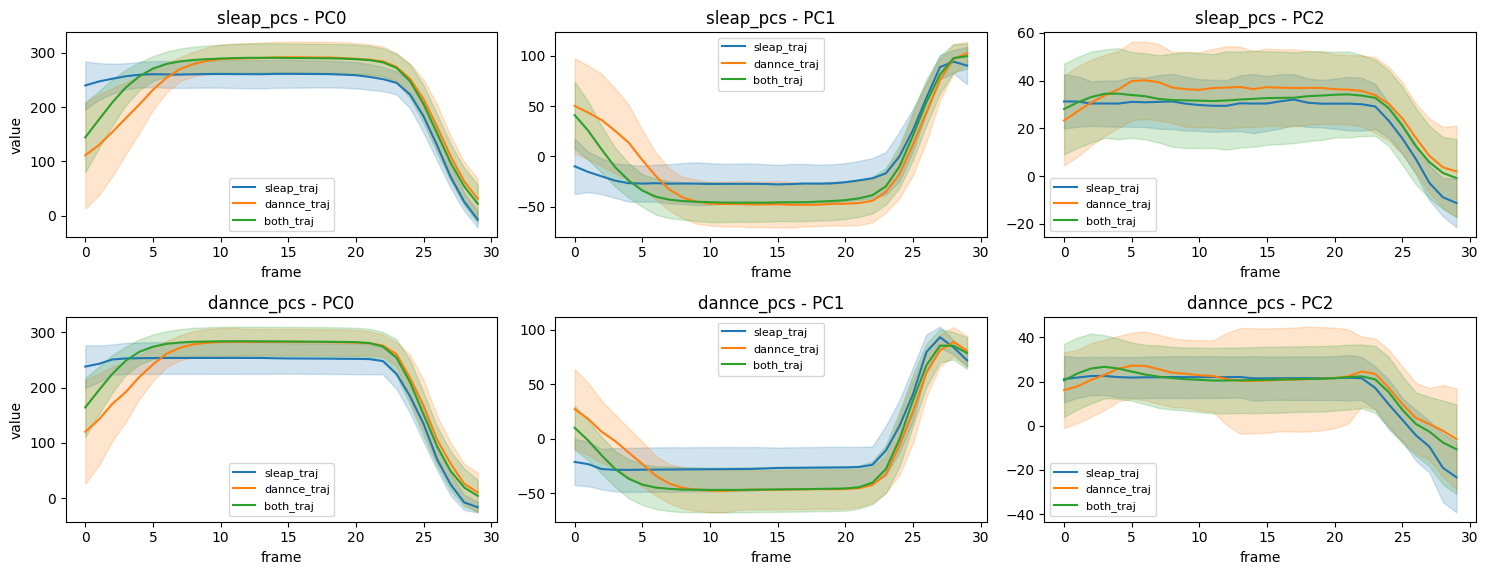

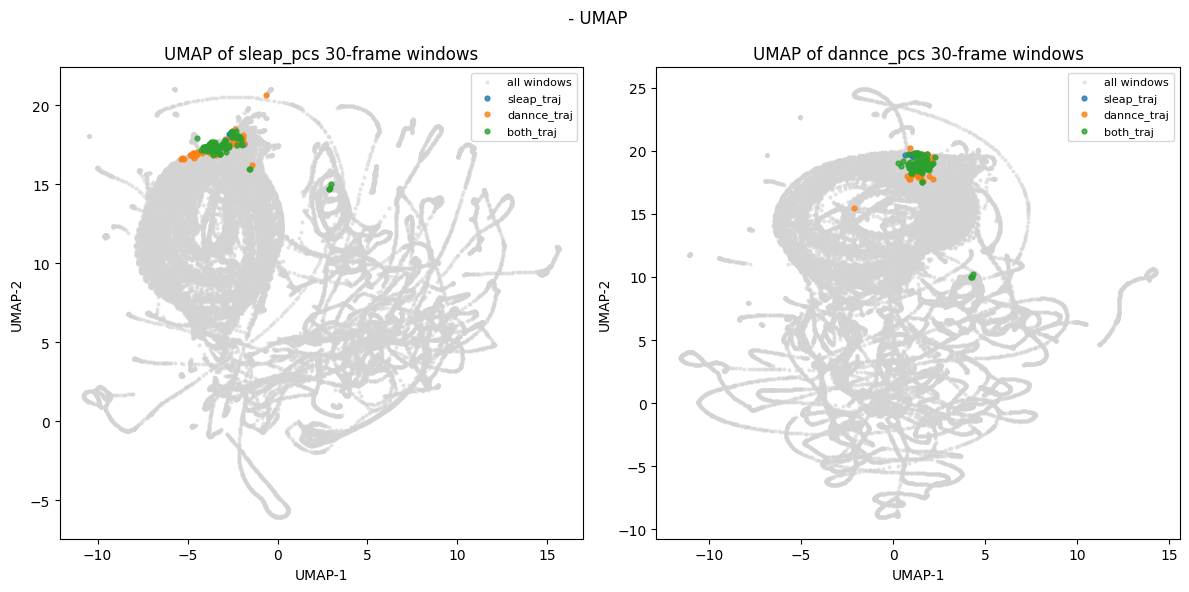

In [144]:
def plot_match_overlap(sleap_pcs, dannce_pcs, sleap_only, dannce_only, both,  
  pc_template, pc_template_bounds, n_components=n_components, title=''):        
      import umap                                                               
                                                                                
      window = 30      
                                                                                
      sleap_traj = np.zeros((len(sleap_only), window, dannce_pcs.shape[1], 2))  
      dannce_traj = np.zeros((len(dannce_only), window, dannce_pcs.shape[1], 2))
      both_traj = np.zeros((len(both), window, dannce_pcs.shape[1], 2))         
                                                                                
      sleap_valid = np.zeros(len(sleap_only), dtype=bool)                       
      dannce_valid = np.zeros(len(dannce_only), dtype=bool)                     
      both_valid = np.zeros(len(both), dtype=bool)                              
                       
      for i, mi in enumerate(sleap_only):                                       
          start = mi - window + 1
          if start < 0:                                                         
              continue 
          sleap_traj[i, :, :, 0] = sleap_pcs[start:mi+1, :]
          sleap_traj[i, :, :, 1] = dannce_pcs[start:mi+1, :]                    
          sleap_valid[i] = True
                                                                                
      for i, mi in enumerate(dannce_only):                                      
          start = mi - window + 1
          if start < 0:                                                         
              continue 
          dannce_traj[i, :, :, 0] = sleap_pcs[start:mi+1, :]
          dannce_traj[i, :, :, 1] = dannce_pcs[start:mi+1, :]                   
          dannce_valid[i] = True
                                                                                
      for i, mi in enumerate(both):                                             
          start = mi - window + 1
          if start < 0:                                                         
              continue
          both_traj[i, :, :, 0] = sleap_pcs[start:mi+1, :]
          both_traj[i, :, :, 1] = dannce_pcs[start:mi+1, :]                     
          both_valid[i] = True
                                                                                
      sleap_traj = sleap_traj[sleap_valid]                                      
      dannce_traj = dannce_traj[dannce_valid]
      both_traj = both_traj[both_valid]                                         
                  
      # ---- Plot 1: mean +- std for each PC, for sleap/dannce/both source streams ----
      fig, axs = plt.subplots(2, n_components, figsize=(5 * n_components, 6),   
  squeeze=False)                                                                
      t = np.arange(window)
      sources = [('sleap_pcs', 0), ('dannce_pcs', 1)]                           
      groups = [                                                                
          ('sleap_traj', sleap_traj, 'tab:blue'),                               
          ('dannce_traj', dannce_traj, 'tab:orange'),                           
          ('both_traj', both_traj, 'tab:green'),                                
      ]           
                                                                                
      for row, (src_name, src_idx) in enumerate(sources):                       
          for pc in range(n_components):
              ax = axs[row, pc]                                                 
              for gname, traj, color in groups:
                  if traj.shape[0] == 0:                                        
                      continue
                  series = traj[:, :, pc, src_idx]                              
                  mean = series.mean(axis=0)                                    
                  std = series.std(axis=0)
                  ax.plot(t, mean, color=color, label=gname)                    
                  ax.fill_between(t, mean - std, mean + std, color=color,       
  alpha=0.2)                                                                    
              ax.set_title(f'{src_name} - PC{pc}')                              
              ax.set_xlabel('frame')                                            
              if pc == 0:
                  ax.set_ylabel('value')                                        
              ax.legend(fontsize=8)
      fig.suptitle(title)                                                       
      fig.tight_layout()                                                        
   
      # ---- Plot 2: UMAP of 30-frame windows, separately for sleap_pcs and dannce_pcs ---- 
      fig2, axs2 = plt.subplots(1, 2, figsize=(12, 6))                          
                  
      def windows_from(pcs):                                                    
          n = pcs.shape[0]
          idx = np.arange(window - 1, n)                                        
          starts = idx - window + 1                                             
          W = np.stack([pcs[s:s + window] for s in starts], axis=0)
          return W.reshape(W.shape[0], -1), idx                                 
                                                                                
      for sp_idx, (src_name, src_pcs, src_sel) in enumerate([                   
          ('sleap_pcs', sleap_pcs, 0),                                          
          ('dannce_pcs', dannce_pcs, 1),                                        
      ]):         
          bg_flat, _ = windows_from(src_pcs)                                    
                                                                                
          def traj_flat(traj):
              if traj.shape[0] == 0:                                            
                  return np.zeros((0, window * src_pcs.shape[1]))               
              return traj[:, :, :, src_sel].reshape(traj.shape[0], -1)
                                                                                
          sleap_flat = traj_flat(sleap_traj)
          dannce_flat = traj_flat(dannce_traj)                                  
          both_flat = traj_flat(both_traj)                                      
   
          all_flat = np.vstack([bg_flat, sleap_flat, dannce_flat, both_flat])   
          reducer = umap.UMAP(n_components=2)
          emb = reducer.fit_transform(all_flat)                                 
                                                                                
          n_bg = bg_flat.shape[0]
          n_s = sleap_flat.shape[0]                                             
          n_d = dannce_flat.shape[0]
          bg_emb = emb[:n_bg]                                                   
          s_emb = emb[n_bg:n_bg + n_s]
          d_emb = emb[n_bg + n_s:n_bg + n_s + n_d]                              
          b_emb = emb[n_bg + n_s + n_d:]
                                                                                
          ax = axs2[sp_idx]
          ax.scatter(bg_emb[:, 0], bg_emb[:, 1], s=4, c='lightgray', alpha=0.5, 
  label='all windows')                                                          
          if n_s:
              ax.scatter(s_emb[:, 0], s_emb[:, 1], s=12, c='tab:blue',          
  alpha=0.8, label='sleap_traj')                                                
          if n_d:                                                               
              ax.scatter(d_emb[:, 0], d_emb[:, 1], s=12, c='tab:orange',        
  alpha=0.8, label='dannce_traj')                                               
          if b_emb.shape[0]:
              ax.scatter(b_emb[:, 0], b_emb[:, 1], s=12, c='tab:green',         
  alpha=0.8, label='both_traj')                                                 
          ax.set_title(f'UMAP of {src_name} 30-frame windows')
          ax.set_xlabel('UMAP-1')                                               
          ax.set_ylabel('UMAP-2')
          ax.legend(fontsize=8)                                                 
                                                                                
      fig2.suptitle(f'{title} - UMAP')
      fig2.tight_layout()                                                       
                                                                                
      return fig, fig2

fig, fig2 = plot_match_overlap(sleap_pcs, dannce_pcs, sleap_only, dannce_only, both, pc_template, pc_template_bounds, n_components=3)

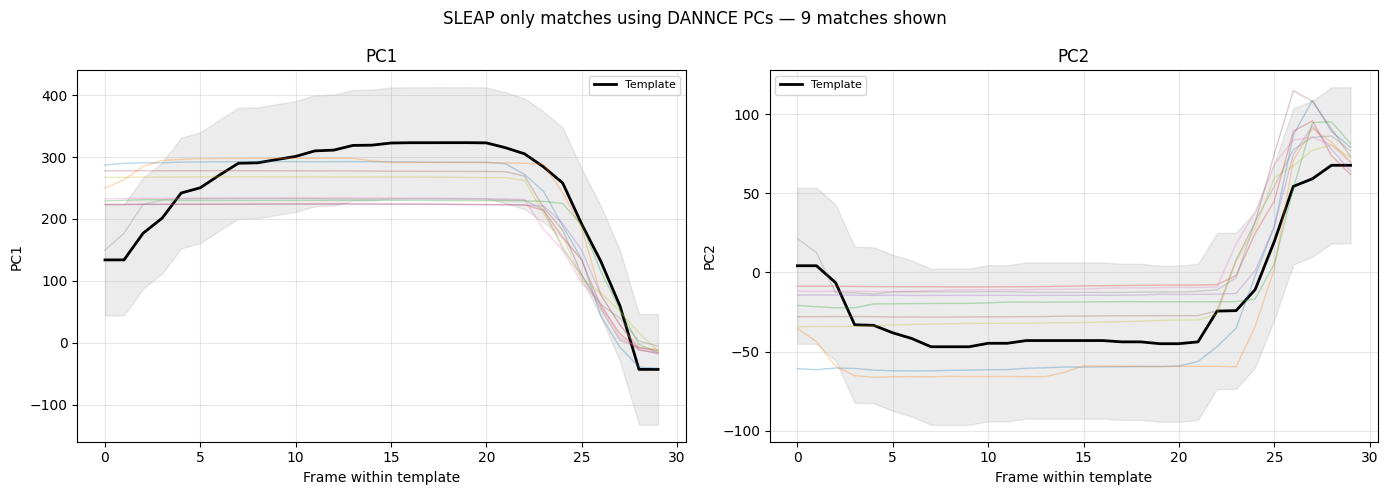

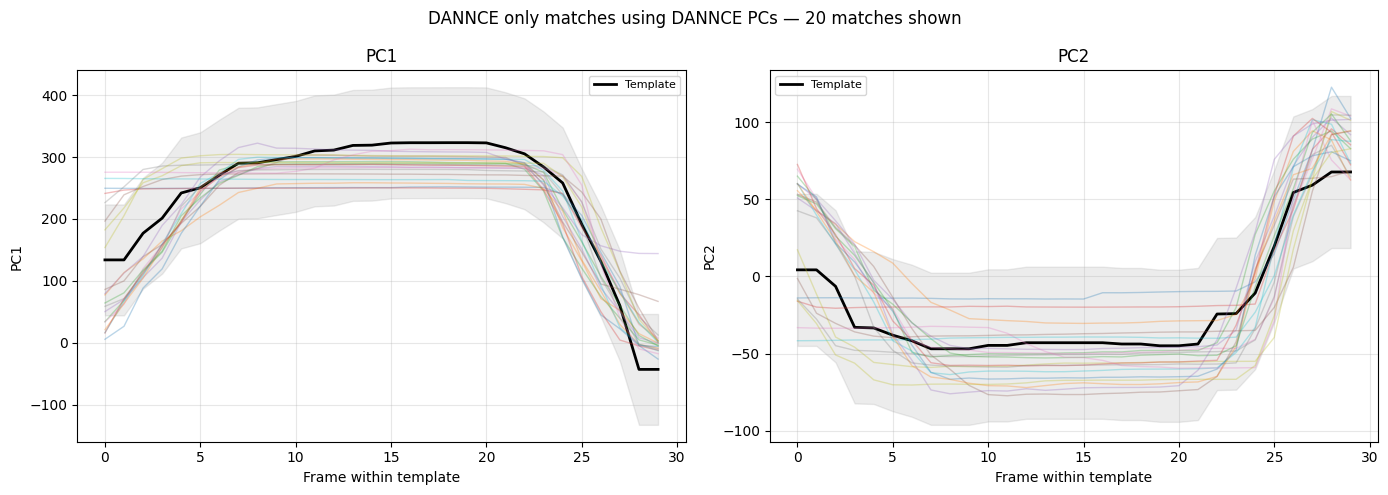

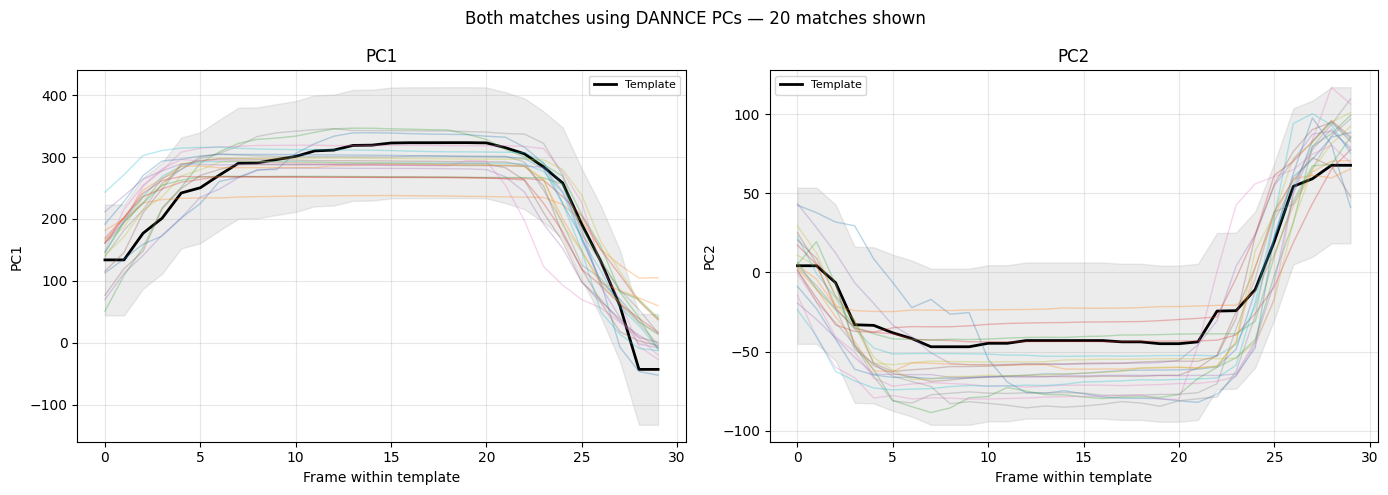

In [145]:
plot_template_matches(dannce_pcs, sleap_only, template_filt, pc_template_bounds,
                      n_components=n_components, title='SLEAP only matches using DANNCE PCs')

plot_template_matches(dannce_pcs, dannce_only, template_filt, pc_template_bounds,
                      n_components=n_components, title='DANNCE only matches using DANNCE PCs')

plot_template_matches(dannce_pcs, both, template_filt, pc_template_bounds,
                      n_components=n_components, title='Both matches using DANNCE PCs')


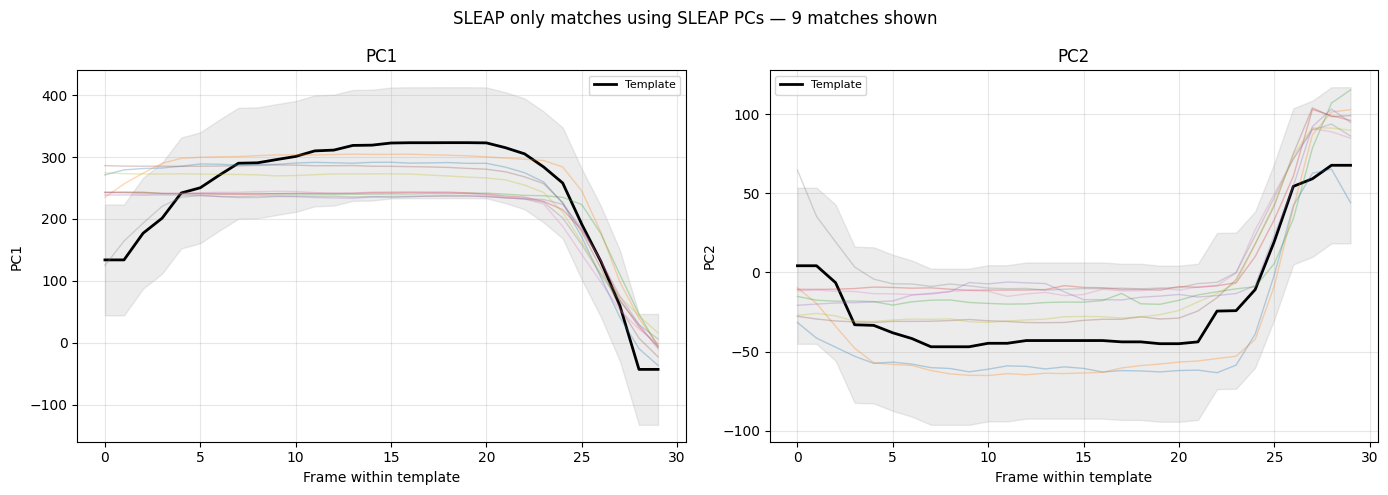

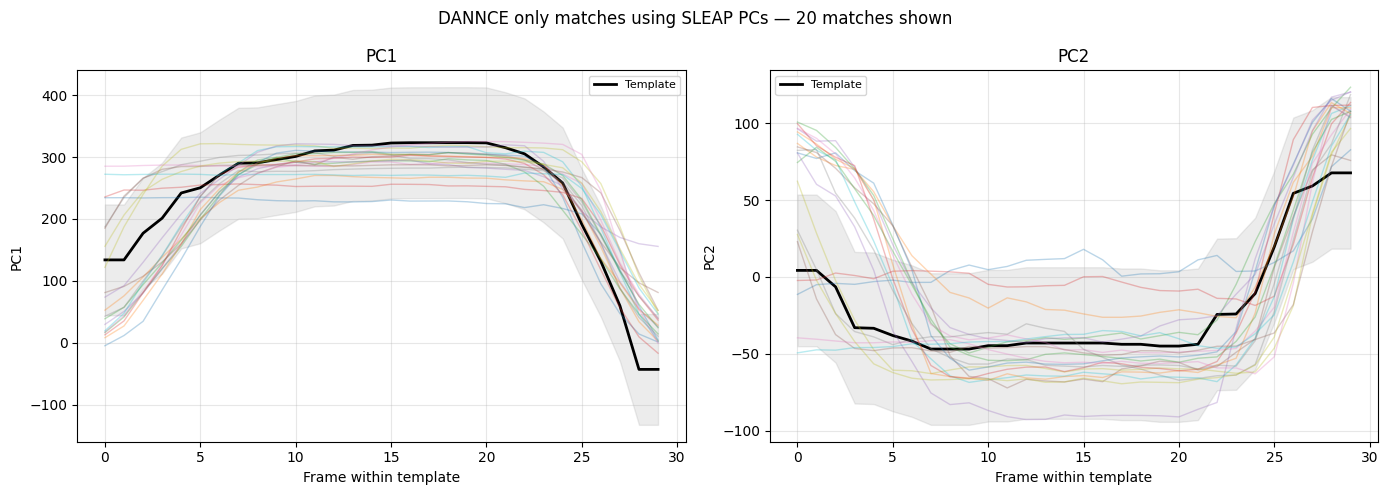

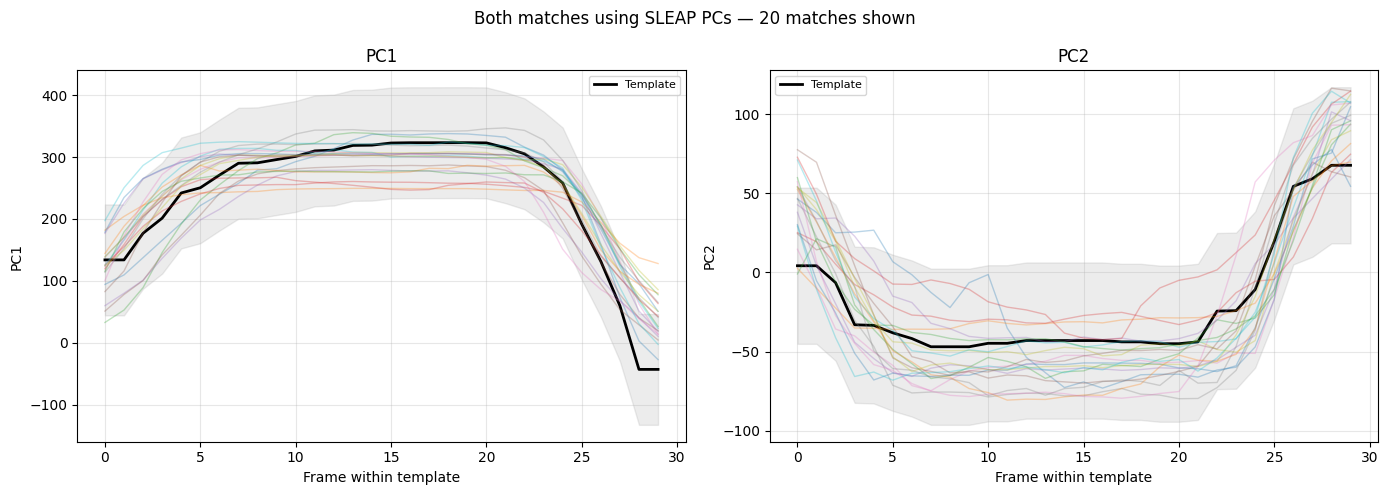

In [146]:
plot_template_matches(sleap_pcs, sleap_only, template_filt, pc_template_bounds,
                      n_components=n_components, title='SLEAP only matches using SLEAP PCs')

plot_template_matches(sleap_pcs, dannce_only, template_filt, pc_template_bounds,
                      n_components=n_components, title='DANNCE only matches using SLEAP PCs')

plot_template_matches(sleap_pcs, both, template_filt, pc_template_bounds,
                      n_components=n_components, title='Both matches using SLEAP PCs')


## Multi-session template match comparison over time

Look at sleap only template matches, dannce only template matches, template matches identified in both. Do not want sleap identifying many templates not identified by dannce or missing templates identified by dannce. Also want to know if there are periods/conditions where the discrepancy is larger or smaller

1. How this changes over time
2. How this depends on the size of the bounds
3. How this depends on the preprocessing approach (size of median filters)

Also show error between DANNCE and SLEAP and how this changes over time

In [ ]:
# Module-level corrector cache so we only load the checkpoint once per
# multi-session sweep, not once per session.
_CORRECTOR_CACHE = {}

def _load_corrector(ckpt_path):
    """Load and cache a corrector checkpoint. Returns (model, ctx, device)."""
    if ckpt_path in _CORRECTOR_CACHE:
        return _CORRECTOR_CACHE[ckpt_path]
    import torch
    from corrector.models import build_model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    kwargs = dict(hidden=ck.get('hidden', 128),
                  n_hidden_layers=ck.get('n_hidden_layers', 2))
    if ck['model_name'] == 'temporal_mlp':
        kwargs['ctx'] = ck.get('ctx', 5)
    model = build_model(ck['model_name'], **kwargs)
    model.load_state_dict(ck['state_dict'])
    model = model.to(device).eval()
    ctx = ck.get('ctx', 1)
    _CORRECTOR_CACHE[ckpt_path] = (model, ctx, device)
    print(f"Loaded corrector {ckpt_path} (model={ck['model_name']} ctx={ctx})")
    return model, ctx, device


def _apply_corrector(sleap_3d, dannce_3d, model, ctx, device,
                     calibration_minutes=5.0, max_residual=60.0):
    """Procrustes-align SLEAP to DANNCE on first 5 min, run MLP, return
    corrected SLEAP in SLEAP world space. Raises if Procrustes residual is
    above max_residual.
    """
    import torch
    from corrector.world_alignment import calibration_indices, fit_procrustes

    sl_w = sleap_3d.astype(np.float32)
    dn_w = dannce_3d.astype(np.float32)
    cal_idx = calibration_indices(len(sl_w), calibration_minutes,
                                   sleap_hz=20.0, n_sample=1000, seed=0)
    tx = fit_procrustes(sl_w[cal_idx], dn_w[cal_idx], try_z_flip=True)
    if tx['residual'] > max_residual:
        raise RuntimeError(
            f"Procrustes residual {tx['residual']:.1f} mm > {max_residual} "
            f"(uncalibrated session — skipping corrector).")

    sl_a = tx['apply'](sl_w).astype(np.float32)
    out = np.empty_like(sl_a)
    if ctx <= 1:
        with torch.no_grad():
            for i in range(0, len(sl_a), 8192):
                xt = torch.from_numpy(sl_a[i:i+8192]).to(device)
                out[i:i+8192] = model(xt).cpu().numpy()
    else:
        T = len(sl_a)
        padded = np.concatenate([np.repeat(sl_a[:1], ctx-1, axis=0), sl_a],
                                axis=0)
        with torch.no_grad():
            for i in range(0, T, 8192):
                idx = np.arange(i, min(i+8192, T))
                wins = np.stack([padded[s:s+ctx] for s in idx], axis=0)
                xt = torch.from_numpy(wins).to(device)
                out[i:i+len(idx)] = model(xt).cpu().numpy()
    return tx['apply_inverse'](out).astype(np.float32)


def get_session_match_stats(rat, session, thresh=5, bound_use=None,
                            sleap_medfilt=11, dannce_medfilt=11,
                            apply_corrector=False,
                            corrector_ckpt='corrector/checkpoints/R1R2R3_world_temporal_mlp.pt'):
    # --- Configuration ---
    template_file = f'{rat}_template_1.npz'
    n_components = 2  # number of PCs for template matching

    # Load template
    template_data = load_template(rat, template_file)
    pc_template = template_data['template'][:,:n_components]
    pc_weights = template_data['pc_weights']
    feature_means = template_data['feature_means']
    bounds = float(template_data['bounds'])
    pcs_to_use = template_data['pcs_to_use']

    template_length = pc_template.shape[0]

    feature_stds = template_data['feature_stds']
    pc_template_bounds = np.ones_like(pc_template) * bounds * feature_stds[:n_components]

    # Load keypoint data
    keys = load_sleap_dannce_keys(rat, session)
    aligned = load_aligned_data(rat, session)
    aligned_indices = aligned['dannce_idx_for_sleap_cams'].astype(int).ravel()[1:]

    sleap_3d = median_filter(keys['sleap_keys_3D'], size=(sleap_medfilt, 1, 1))
    dannce_3d = keys['dannce_keys_3D']
    if dannce_3d.ndim == 4:
        dannce_3d = dannce_3d.squeeze(axis=1).transpose(0, 2, 1)
    else:
        dannce_3d = np.transpose(dannce_3d, [0, 2, 1])
    dannce_3d = dannce_3d[aligned_indices, :, :]
    dannce_3d = median_filter(dannce_3d, size=(dannce_medfilt, 1, 1))

    # Optional corrector — replaces sleap_3d with corrected world-space coords
    if apply_corrector:
        model, ctx, device = _load_corrector(corrector_ckpt)
        sleap_3d = _apply_corrector(sleap_3d, dannce_3d, model, ctx, device)

    # SLEAP: flip z, normalize, project
    sleap_flipped = sleap_3d.copy()
    sleap_flipped[:, :, 2] = -sleap_flipped[:, :, 2]
    sleap_rotated, _, _ = normalize_skeleton_batch(sleap_flipped)
    sleap_pcs = project_to_pcs(sleap_rotated, pc_weights, feature_means)

    # DANNCE: normalize, project
    dannce_rotated, _, _ = normalize_skeleton_batch(dannce_3d)
    dannce_pcs = project_to_pcs(dannce_rotated, pc_weights, feature_means)

    pc_error = np.mean((dannce_pcs - sleap_pcs)**2, axis=0)

    sleap_matches, _ = get_template_match_indices(
        sleap_pcs[:, :n_components], pc_template, pc_template_bounds,
        refractory_frames=template_length)
    print(f'SLEAP offline matches: {len(sleap_matches)}')

    dannce_matches, _ = get_template_match_indices(
        dannce_pcs[:, :n_components], pc_template, pc_template_bounds,
        refractory_frames=template_length)
    print(f'DANNCE offline matches: {len(dannce_matches)}')

    sleap_only, dannce_only, both = get_match_overlap(dannce_matches, sleap_matches)
    return sleap_only, dannce_only, both, pc_error

In [28]:
rat = 'R2'
df = load_session_df()
rat_sessions = df[df['rat'] == rat]['session'].tolist()

session_list = [(rat, s) for s in rat_sessions]
print(f'Will process {len(session_list)} sessions for {rat}')

Will process 75 sessions for R2


In [ ]:
def track_template_across_sessions(session_list, thresh=5,
                                   apply_corrector=False,
                                   corrector_ckpt='corrector/checkpoints/R1R2R3_world_temporal_mlp.pt'):
    results = {'session': [], 'sleap_only': [], 'dannce_only': [],
               'both': [], 'pc_error': []}
    for rat, session in session_list:
        try:
            sleap_only, dannce_only, both, pc_error = get_session_match_stats(
                rat, session, thresh=thresh,
                apply_corrector=apply_corrector,
                corrector_ckpt=corrector_ckpt)
            results['session'].append(session)
            results['sleap_only'].append(sleap_only)
            results['dannce_only'].append(dannce_only)
            results['both'].append(both)
            results['pc_error'].append(pc_error)
            print(f'{session} processed')
        except Exception as e:
            print(f'{session} FAILED: {e}')
    return results

In [30]:
results = track_template_across_sessions(session_list, thresh=10)

SLEAP offline matches: 73
DANNCE offline matches: 52
2025_09_29_1 processed
SLEAP offline matches: 22
DANNCE offline matches: 26
2025_09_30_1 processed
SLEAP offline matches: 6
DANNCE offline matches: 4
2025_10_02_2 processed
SLEAP offline matches: 31
DANNCE offline matches: 21
2025_10_28_2 processed
SLEAP offline matches: 32
DANNCE offline matches: 31
2025_10_29_2 processed
SLEAP offline matches: 36
DANNCE offline matches: 24
2025_10_30_1 processed
SLEAP offline matches: 46
DANNCE offline matches: 36
2025_10_31_2 processed
SLEAP offline matches: 36
DANNCE offline matches: 33
2025_11_01_2 processed
SLEAP offline matches: 34
DANNCE offline matches: 27
2025_11_03_2 processed
SLEAP offline matches: 5
DANNCE offline matches: 1
2025_11_04_1 processed
SLEAP offline matches: 50
DANNCE offline matches: 49
2025_11_06_2 processed
SLEAP offline matches: 22
DANNCE offline matches: 24
2025_11_07_2 processed
SLEAP offline matches: 24
DANNCE offline matches: 29
2025_11_08_2 processed
SLEAP offline ma

In [ ]:
from visualization import session_to_datetime

def plot_template_match_results(results, max_pcs=4, save_path_prefix=None,
                                 title_suffix='', show=True):
    """Plot multi-session template match statistics.

    If save_path_prefix is given, the three figures are saved to:
        {save_path_prefix}_match_counts.png
        {save_path_prefix}_pc_error.png
        {save_path_prefix}_match_pct.png
    title_suffix is appended to each plot title (e.g. 'R3 corrected').
    show=False suppresses plt.show() — useful when batching.
    """
    import os
    sessions = results['session']
    try:
        order = sorted(range(len(sessions)),
                       key=lambda i: session_to_datetime(sessions[i]))
    except Exception:
        order = list(range(len(sessions)))

    sessions_sorted   = [sessions[i] for i in order]
    sleap_only_sorted = [len(results['sleap_only'][i])  for i in order]
    dannce_only_sorted = [len(results['dannce_only'][i]) for i in order]
    both_sorted        = [len(results['both'][i])        for i in order]
    pc_error_sorted    = [results['pc_error'][i]         for i in order]
    x = np.arange(len(sessions_sorted))

    if save_path_prefix:
        d = os.path.dirname(save_path_prefix)
        if d:
            os.makedirs(d, exist_ok=True)

    # --- Plot 1: match counts ---
    fig1, ax1 = plt.subplots(figsize=(max(10, len(sessions_sorted) * 0.35), 5))
    ax1.plot(x, both_sorted,       'o-',  color='steelblue', linewidth=1.5, label='Both')
    ax1.plot(x, sleap_only_sorted, 's--', color='cyan',      linewidth=1.5, label='SLEAP only',  alpha=0.85)
    ax1.plot(x, dannce_only_sorted,'D--', color='magenta',   linewidth=1.5, label='DANNCE only', alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(sessions_sorted, rotation=45, ha='right', fontsize=7)
    ax1.set_ylabel('Template match count')
    title = 'Offline template matches per session'
    if title_suffix:
        title = f'{title} — {title_suffix}'
    ax1.set_title(title)
    ax1.legend(); ax1.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path_prefix:
        fig1.savefig(f'{save_path_prefix}_match_counts.png', dpi=130)
    if show: plt.show()
    else: plt.close(fig1)

    # --- Plot 2: PC error ---
    n_pcs = min(max_pcs, len(pc_error_sorted[0]))
    colors = plt.cm.tab10(np.linspace(0, 1, n_pcs))
    fig2, ax2 = plt.subplots(figsize=(max(10, len(sessions_sorted) * 0.35), 5))
    for pc_idx in range(n_pcs):
        errors = [pc_error_sorted[i][pc_idx] for i in range(len(sessions_sorted))]
        ax2.plot(x, errors, 'o-', color=colors[pc_idx], linewidth=1.5,
                 label=f'PC {pc_idx + 1}', alpha=0.85)
    ax2.set_xticks(x)
    ax2.set_xticklabels(sessions_sorted, rotation=45, ha='right', fontsize=7)
    ax2.set_ylabel('Mean squared PC error (DANNCE vs SLEAP)')
    title = 'PC discrepancy between SLEAP and DANNCE across sessions'
    if title_suffix:
        title = f'{title} — {title_suffix}'
    ax2.set_title(title)
    ax2.legend(); ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path_prefix:
        fig2.savefig(f'{save_path_prefix}_pc_error.png', dpi=130)
    if show: plt.show()
    else: plt.close(fig2)

    # --- Plot 3: match percentages ---
    totals = [sleap_only_sorted[i] + dannce_only_sorted[i] + both_sorted[i]
              for i in range(len(sessions_sorted))]
    def safe_pct(counts, totals):
        return [100.0 * c / t if t > 0 else np.nan for c, t in zip(counts, totals)]
    both_pct = safe_pct(both_sorted, totals)
    sleap_only_pct = safe_pct(sleap_only_sorted, totals)
    dannce_only_pct = safe_pct(dannce_only_sorted, totals)

    fig3, ax3 = plt.subplots(figsize=(max(10, len(sessions_sorted) * 0.35), 5))
    ax3.plot(x, both_pct,        'o-',  color='steelblue', linewidth=1.5, label='Both')
    ax3.plot(x, sleap_only_pct,  's--', color='cyan',      linewidth=1.5, label='SLEAP only',  alpha=0.85)
    ax3.plot(x, dannce_only_pct, 'D--', color='magenta',   linewidth=1.5, label='DANNCE only', alpha=0.85)
    ax3.set_xticks(x)
    ax3.set_xticklabels(sessions_sorted, rotation=45, ha='right', fontsize=7)
    ax3.set_ylabel('% of total matches')
    ax3.set_ylim(0, 100)
    title = 'Offline template matches as % of total per session'
    if title_suffix:
        title = f'{title} — {title_suffix}'
    ax3.set_title(title)
    ax3.legend(); ax3.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    if save_path_prefix:
        fig3.savefig(f'{save_path_prefix}_match_pct.png', dpi=130)
    if show: plt.show()
    else: plt.close(fig3)
    return fig1, fig2, fig3


fig1, fig2, fig3 = plot_template_match_results(results, max_pcs=4)

## Multi-rat raw vs corrected sweep

Run all three rats with both raw SLEAP and corrected SLEAP (using the temporal R1+R2+R3 model) and save the resulting figures to `corrector/figures/multi_session/`.

In [ ]:
import os
RAT_LIST = ['R1', 'R2', 'R3']
MODES = [('raw', False), ('corrected', True)]
OUT_DIR = 'corrector/figures/multi_session'
os.makedirs(OUT_DIR, exist_ok=True)

df = load_session_df()
all_results = {}
for rat in RAT_LIST:
    rat_sessions = df[df['rat'] == rat]['session'].tolist()
    session_list = [(rat, s) for s in rat_sessions]
    for mode_label, apply in MODES:
        print(f"\n=== {rat} ({mode_label}) over {len(session_list)} sessions ===")
        results = track_template_across_sessions(
            session_list, thresh=10, apply_corrector=apply)
        all_results[(rat, mode_label)] = results
        prefix = f'{OUT_DIR}/{rat}_{mode_label}'
        plot_template_match_results(
            results, max_pcs=4, save_path_prefix=prefix,
            title_suffix=f'{rat} {mode_label}', show=False)
        print(f'  saved figures to {prefix}_*.png')

## Generate template match video

In [ ]:
# Uncomment to generate video of template matches
# from config import sleap_video_path
#
# video_file = sleap_video_path(rat, session)
# output_video = f'template_matches_{rat}_{session}.mp4'
#
# from animations import save_template_matches_video
# save_template_matches_video(
#     sleap_matches, pc_template, pc_template_bounds,
#     sleap_3d, sleap_pcs, EDGES,
#     video_file, output_video,
#     n_components=n_components, max_matches=5
# )